In [ ]:
# ============================================================
# Phase 3: Deployment and monitoring
# Setup: imports, paths, reproducibility, device.
# ============================================================

import os
import json
import time
import random
from pathlib import Path
from copy import deepcopy
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT     = Path("/content/drive/MyDrive/comp8430_project")
PHONE_DATA_DIR   = PROJECT_ROOT / "data" / "resized_256"          # 19-class phone data
ROBOT_DATA_DIR   = PROJECT_ROOT / "data" / "robot_resized_256"    # 3-class robot data
OUTPUT_DIR       = PROJECT_ROOT / "outputs"
PHASE2_MODEL_DIR = OUTPUT_DIR / "models_phase2"
FIG_DIR          = OUTPUT_DIR / "figures_phase3"
MODEL_DIR        = OUTPUT_DIR / "models_phase3"
LOG_DIR          = OUTPUT_DIR / "logs"

for d in [FIG_DIR, MODEL_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

assert PHONE_DATA_DIR.exists(),  f"Phone data dir not found:  {PHONE_DATA_DIR}"
assert ROBOT_DATA_DIR.exists(),  f"Robot data dir not found:  {ROBOT_DATA_DIR}"
assert PHASE2_MODEL_DIR.exists(),f"Phase 2 model dir missing: {PHASE2_MODEL_DIR}"

# The Phase 2 best-on-19-class checkpoint we'll load and adapt
PHASE2_CKPT = PHASE2_MODEL_DIR / "resnet50_R1_last_const_mild_all.pt"
assert PHASE2_CKPT.exists(), f"Phase 2 checkpoint not found at {PHASE2_CKPT}"

print(f"PyTorch:        {torch.__version__}")
print(f"Torchvision:    {torchvision.__version__}")
print(f"Device:         {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU:            {torch.cuda.get_device_name(0)}")
print(f"Phone data:     {PHONE_DATA_DIR}")
print(f"Robot data:     {ROBOT_DATA_DIR}")
print(f"Phase 2 ckpt:   {PHASE2_CKPT}")

Mounted at /content/drive
PyTorch:        2.11.0+cu128
Torchvision:    0.26.0+cu128
Device:         cuda
GPU:            NVIDIA L4
Phone data:     /content/drive/MyDrive/comp8430_project/data/resized_256
Robot data:     /content/drive/MyDrive/comp8430_project/data/robot_resized_256
Phase 2 ckpt:   /content/drive/MyDrive/comp8430_project/outputs/models_phase2/resnet50_R1_last_const_mild_all.pt


In [ ]:
# ============================================================
# Inventory the robot dataset: 3 classes, ~70 images each.
# Prints per-class counts and verifies expected class names.
# ============================================================

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}

EXPECTED_ROBOT_CLASSES = sorted([
    "cocacola__classic",
    "monster__zero_sugar",
    "redbull__tropical",
])

robot_class_dirs = sorted([d for d in ROBOT_DATA_DIR.iterdir() if d.is_dir()])
print(f"Found {len(robot_class_dirs)} class folders in {ROBOT_DATA_DIR}:\n")

robot_counts = {}
for d in robot_class_dirs:
    imgs = [f for f in d.iterdir() if f.suffix.lower() in IMG_EXTS]
    robot_counts[d.name] = len(imgs)
    marker = "" if d.name in EXPECTED_ROBOT_CLASSES else "  [!] unexpected class name"
    print(f"  {d.name:<40s} {len(imgs):>4d} images{marker}")

# Verify the expected classes are all present
missing = set(EXPECTED_ROBOT_CLASSES) - set(robot_counts.keys())
assert not missing, f"Missing expected classes: {missing}"

total = sum(robot_counts.values())
print(f"\nTotal: {total} images across {len(robot_class_dirs)} classes")
print(f"Min/max per class: {min(robot_counts.values())} / {max(robot_counts.values())}")

Found 3 class folders in /content/drive/MyDrive/comp8430_project/data/robot_resized_256:

  cocacola__classic                          66 images
  monster__zero_sugar                        72 images
  redbull__tropical                          72 images

Total: 210 images across 3 classes
Min/max per class: 66 / 72


In [ ]:
# ============================================================
# Split the robot images per-class into a fine-tune set (45) and
# a test set (the remainder). Persisted as JSON for reproducibility.
# Paths are stored relative to ROBOT_DATA_DIR for portability.
# ============================================================

ROBOT_SPLITS_FILE = LOG_DIR / "robot_splits.json"
FINETUNE_PER_CLASS = 45

by_class_robot = {}
for cdir in robot_class_dirs:
    files = sorted([f.relative_to(ROBOT_DATA_DIR).as_posix()
                    for f in cdir.iterdir()
                    if f.suffix.lower() in IMG_EXTS])
    by_class_robot[cdir.name] = files

rng = random.Random(SEED)

robot_splits = {"finetune": [], "test": []}
split_summary = {}

for cname in sorted(by_class_robot.keys()):
    files = by_class_robot[cname][:]
    rng.shuffle(files)
    n = len(files)
    n_ft = min(FINETUNE_PER_CLASS, n)         # cap at the available count
    n_te = n - n_ft
    robot_splits["finetune"].extend((f, cname) for f in files[:n_ft])
    robot_splits["test"].extend((f, cname)     for f in files[n_ft:])
    split_summary[cname] = {"total": n, "finetune": n_ft, "test": n_te}

with open(ROBOT_SPLITS_FILE, "w") as f:
    json.dump({
        "seed": SEED,
        "finetune_per_class": FINETUNE_PER_CLASS,
        "data_dir": str(ROBOT_DATA_DIR),
        "splits": {k: [list(t) for t in v] for k, v in robot_splits.items()},
    }, f, indent=2)

print(f"{'class':<35s} {'total':>6s} {'finetune':>9s} {'test':>5s}")
print("-" * 60)
for cname, s in split_summary.items():
    print(f"{cname:<35s} {s['total']:>6d} {s['finetune']:>9d} {s['test']:>5d}")
print("-" * 60)
totals = {k: sum(s[k] for s in split_summary.values())
          for k in ["total", "finetune", "test"]}
print(f"{'TOTAL':<35s} {totals['total']:>6d} {totals['finetune']:>9d} {totals['test']:>5d}")
print(f"\nSaved: {ROBOT_SPLITS_FILE}")

class                                total  finetune  test
------------------------------------------------------------
cocacola__classic                       66        45    21
monster__zero_sugar                     72        45    27
redbull__tropical                       72        45    27
------------------------------------------------------------
TOTAL                                  210       135    75

Saved: /content/drive/MyDrive/comp8430_project/outputs/logs/robot_splits.json


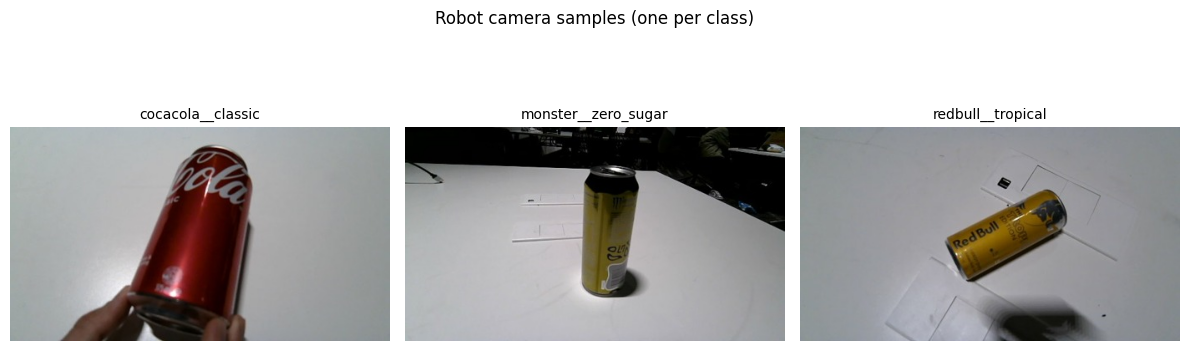

Saved: /content/drive/MyDrive/comp8430_project/outputs/figures_phase3/robot_samples.png


In [ ]:
# ============================================================
# Show one random sample per robot class.
# ============================================================

import random as _r
_r.seed(SEED)

robot_class_names = sorted(by_class_robot.keys())
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, cname in zip(axes, robot_class_names):
    files = [f for f in (ROBOT_DATA_DIR / cname).iterdir()
             if f.suffix.lower() in IMG_EXTS]
    img_path = _r.choice(files)
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(cname, fontsize=10)
    ax.axis("off")

plt.suptitle("Robot camera samples (one per class)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "robot_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'robot_samples.png'}")

In [ ]:
# ============================================================
# Load the Phase 2 best model: resnet50_R1_last_const_mild_all
# (test accuracy 0.9934 on the 19-class test set).
#
# The checkpoint contains:
#   - model state_dict (weights for 19-class head + backbone)
#   - class_to_idx mapping (so we know which class is which index)
#   - history, info, hyperparameters (for reference)
#
# Rebuild the model architecture, load the weights, and verify.
# ============================================================

# ---- Load the checkpoint dictionary ----
ckpt = torch.load(PHASE2_CKPT, map_location=DEVICE, weights_only=False)
print(f"Loaded checkpoint: {PHASE2_CKPT.name}")
print(f"  model_name:    {ckpt['model_name']}")
print(f"  strategy:      {ckpt['strategy']}")
print(f"  schedule:      {ckpt['schedule']}")
print(f"  best_val_acc:  {ckpt['best_val_acc']:.4f}  at epoch {ckpt['best_epoch']}")

# ---- Reconstruct the 19-class index from the checkpoint ----
PHASE2_CLASS_TO_IDX = ckpt["class_to_idx"]
PHASE2_IDX_TO_CLASS = {i: c for c, i in PHASE2_CLASS_TO_IDX.items()}
NUM_PHASE2_CLASSES  = len(PHASE2_CLASS_TO_IDX)
print(f"  num classes:   {NUM_PHASE2_CLASSES}")
assert NUM_PHASE2_CLASSES == 19, "Expected 19 classes in the Phase 2 checkpoint"

# ---- Rebuild the model architecture ----
# Same as Phase 2: pretrained ResNet-50, replace fc with 19-way Linear.
# We load weights WITHOUT downloading the ImageNet weights again, since
# the checkpoint state_dict will overwrite them.
phase2_model = resnet50(weights=None)
phase2_model.fc = nn.Linear(phase2_model.fc.in_features, NUM_PHASE2_CLASSES)
missing, unexpected = phase2_model.load_state_dict(ckpt["state_dict"], strict=True)
phase2_model.to(DEVICE)
phase2_model.eval()
print(f"\nLoaded weights into 19-class ResNet-50")
print(f"  Missing keys:    {len(missing)}  (should be 0)")
print(f"  Unexpected keys: {len(unexpected)}  (should be 0)")

# ---- Sanity check: 19-class index alphabetical and matches what we expect ----
print(f"\nPhase 2 class index:")
for i, c in PHASE2_IDX_TO_CLASS.items():
    print(f"  {i:>2d}  {c}")

# ---- Identify which Phase 2 indices correspond to our 3 robot classes ----
ROBOT_CLASSES = EXPECTED_ROBOT_CLASSES  # alphabetical: cocacola__classic, monster__zero_sugar, redbull__tropical
ROBOT_CLASS_TO_PHASE2_IDX = {c: PHASE2_CLASS_TO_IDX[c] for c in ROBOT_CLASSES}
print(f"\nRobot classes Phase 2 indices:")
for c, idx in ROBOT_CLASS_TO_PHASE2_IDX.items():
    print(f"  {c:<35s}  Phase 2 class index {idx}")

Loaded checkpoint: resnet50_R1_last_const_mild_all.pt
  model_name:    resnet50
  strategy:      last_block
  schedule:      constant
  best_val_acc:  0.9800  at epoch 8
  num classes:   19

Loaded weights into 19-class ResNet-50
  Missing keys:    0  (should be 0)
  Unexpected keys: 0  (should be 0)

Phase 2 class index:
   0  cocacola__classic
   1  cocacola__diet
   2  cocacola__vanilla
   3  cocacola__zero
   4  monster__ultra_blue_hawaiian
   5  monster__ultra_fiesta
   6  monster__ultra_strawberry_dreams
   7  monster__zero_sugar
   8  monster__zero_ultra
   9  redbull__berry
  10  redbull__classic
  11  redbull__red
  12  redbull__sugar_free
  13  redbull__tropical
  14  v__blue
  15  v__raspberry_lemonade
  16  v__refresh
  17  v__strawberries_cream
  18  v__zero_sugar

Robot classes → Phase 2 indices:
  cocacola__classic                   → Phase 2 class index 0
  monster__zero_sugar                 → Phase 2 class index 7
  redbull__tropical                   → Phase 2 class 

In [ ]:
# ============================================================
# Eval 1: Phase 2 model (no further training) on robot test set.
# Reports two accuracy numbers per class:
#   strict:     argmax over all 19 logits == correct
#   restricted: argmax over only the 3 robot-class logits == correct
# ============================================================

# Same eval transform as Phase 2 (must match training-time normalisation).
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

tf_eval = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Dataset class for robot data.
class RobotDataset(Dataset):
    def __init__(self, data_dir, entries, transform):
        self.data_dir = Path(data_dir)
        self.entries = entries     # list of (relative_path, class_name)
        self.transform = transform

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        rel_path, cname = self.entries[idx]
        img = Image.open(self.data_dir / rel_path).convert("RGB")
        return self.transform(img), cname  # return class NAME, not index, here

with open(ROBOT_SPLITS_FILE) as f:
    robot_split_doc = json.load(f)

robot_test_ds = RobotDataset(ROBOT_DATA_DIR, robot_split_doc["splits"]["test"], tf_eval)
robot_test_loader = DataLoader(robot_test_ds, batch_size=32, shuffle=False,
                               num_workers=2, pin_memory=True)

# Run the Phase 2 model over robot test set, collect 19-way logits per image.
@torch.no_grad()
def predict_19way(model, loader):
    model.eval()
    all_logits = []
    all_true_names = []
    for imgs, names in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        logits = model(imgs)
        all_logits.append(logits.cpu().numpy())
        all_true_names.extend(names)
    return np.concatenate(all_logits, axis=0), all_true_names

logits, true_names = predict_19way(phase2_model, robot_test_loader)
print(f"Predicted on {len(true_names)} robot test images")
print(f"Logits shape: {logits.shape}  (should be N \u00d7 19)")

# ---- Convert logits to predictions and accuracy metrics ----
robot_indices_in_phase2 = [PHASE2_CLASS_TO_IDX[c] for c in ROBOT_CLASSES]
true_idx_p2 = np.array([PHASE2_CLASS_TO_IDX[n] for n in true_names])

# Strict: argmax over all 19
pred_strict = logits.argmax(axis=1)
correct_strict = (pred_strict == true_idx_p2)

# Restricted: argmax over only the 3 robot-class columns
restricted_logits = logits[:, robot_indices_in_phase2]    # N x 3
pred_restricted_in3 = restricted_logits.argmax(axis=1)
# Map this 0/1/2 prediction back to the original Phase 2 index
pred_restricted = np.array([robot_indices_in_phase2[p] for p in pred_restricted_in3])
correct_restricted = (pred_restricted == true_idx_p2)

# ---- Per-class breakdown ----
print(f"\n{'class':<30s} {'n':>4s} {'strict_acc':>11s} {'restr_acc':>10s}")
print("-" * 60)
for cname in ROBOT_CLASSES:
    mask = true_idx_p2 == PHASE2_CLASS_TO_IDX[cname]
    n = mask.sum()
    s_acc = correct_strict[mask].mean() if n else 0
    r_acc = correct_restricted[mask].mean() if n else 0
    print(f"{cname:<30s} {n:>4d} {s_acc:>11.4f} {r_acc:>10.4f}")
print("-" * 60)
print(f"{'OVERALL':<30s} {len(true_names):>4d} "
      f"{correct_strict.mean():>11.4f} {correct_restricted.mean():>10.4f}")

# ---- Show the "wrong" predictions and what class the model picked instead ----
print(f"\nMisclassifications under the strict 19-way model:")
wrong = ~correct_strict
if wrong.sum() == 0:
    print("  (none)")
else:
    print(f"{'idx':>4s}  {'true':<30s} {'predicted':<35s} {'conf':>6s}")
    print("-" * 80)
    probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
    for i in np.where(wrong)[0]:
        true_c = true_names[i]
        pred_c = PHASE2_IDX_TO_CLASS[pred_strict[i]]
        conf = probs[i, pred_strict[i]]
        print(f"{i:>4d}  {true_c:<30s} {pred_c:<35s} {conf:>6.3f}")

# Save Eval 1 results for the report
np.save(LOG_DIR / "phase3_eval1_logits.npy", logits)
with open(LOG_DIR / "phase3_eval1_metrics.json", "w") as f:
    json.dump({
        "n_test": len(true_names),
        "strict_acc_overall": float(correct_strict.mean()),
        "restricted_acc_overall": float(correct_restricted.mean()),
        "per_class": {
            c: {
                "n": int((true_idx_p2 == PHASE2_CLASS_TO_IDX[c]).sum()),
                "strict_acc": float(correct_strict[true_idx_p2 == PHASE2_CLASS_TO_IDX[c]].mean()),
                "restricted_acc": float(correct_restricted[true_idx_p2 == PHASE2_CLASS_TO_IDX[c]].mean()),
            } for c in ROBOT_CLASSES
        }
    }, f, indent=2)
print(f"\nSaved Eval 1 metrics to {LOG_DIR / 'phase3_eval1_metrics.json'}")

Predicted on 75 robot test images
Logits shape: (75, 19)  (should be N × 19)

class                             n  strict_acc  restr_acc
------------------------------------------------------------
cocacola__classic                21      0.7619     1.0000
monster__zero_sugar              27      0.8148     0.8148
redbull__tropical                27      0.7778     1.0000
------------------------------------------------------------
OVERALL                          75      0.7867     0.9333

Misclassifications under the strict 19-way model:
 idx  true                           predicted                             conf
--------------------------------------------------------------------------------
   0  cocacola__classic              v__strawberries_cream                0.336
   8  cocacola__classic              v__strawberries_cream                0.471
  10  cocacola__classic              redbull__sugar_free                  0.227
  13  cocacola__classic              redbull__red    

In [ ]:
# ============================================================
# Build the 3-class transfer model from the Phase 2 checkpoint.
#
# Strategy:
#   - Keep all backbone weights from the Phase 2 best model
#   - Replace the final 19-way Linear head with a fresh 3-way Linear head
#   - Use the same "last_block" freezing strategy as Phase 2's R1:
#     unfreeze layer4 + the new head, freeze everything earlier.
# ============================================================

ROBOT_NUM_CLASSES = 3
ROBOT_CLASS_TO_IDX = {c: i for i, c in enumerate(ROBOT_CLASSES)}
ROBOT_IDX_TO_CLASS = {i: c for c, i in ROBOT_CLASS_TO_IDX.items()}

def build_robot_model(phase2_state_dict):
    """Build a ResNet-50, load Phase 2 backbone weights, replace head with 3-way."""
    model = resnet50(weights=None)

    # First, give the model the same 19-way head shape so the state_dict loads.
    model.fc = nn.Linear(model.fc.in_features, NUM_PHASE2_CLASSES)
    model.load_state_dict(phase2_state_dict, strict=True)

    # Now swap the head for a fresh 3-way Linear.
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, ROBOT_NUM_CLASSES)

    # Apply the same freezing strategy as Phase 2 R1: unfreeze layer4 + head.
    for p in model.parameters():
        p.requires_grad = False
    for p in model.layer4.parameters():
        p.requires_grad = True
    for p in model.fc.parameters():
        p.requires_grad = True

    # Build parameter groups with discriminative LRs (same as Phase 2 R1).
    param_groups = [
        {"params": model.layer4.parameters(), "lr": 1e-4},
        {"params": model.fc.parameters(),     "lr": 1e-3},
    ]
    return model.to(DEVICE), param_groups

robot_model, robot_param_groups = build_robot_model(ckpt["state_dict"])

# Verification print
n_total     = sum(p.numel() for p in robot_model.parameters())
n_trainable = sum(p.numel() for p in robot_model.parameters() if p.requires_grad)
print(f"Robot model built:")
print(f"  Total params:       {n_total/1e6:.2f}M")
print(f"  Trainable params:   {n_trainable/1e6:.2f}M  ({n_trainable/n_total*100:.2f}%)")
print(f"  Trainable groups:   {len(robot_param_groups)}  "
      f"(LRs: {[g['lr'] for g in robot_param_groups]})")
print(f"  Output head:        {robot_model.fc}")
print(f"\nRobot class index:")
for i, c in ROBOT_IDX_TO_CLASS.items():
    print(f"  {i}  {c}")

Robot model built:
  Total params:       23.51M
  Trainable params:   14.97M  (63.67%)
  Trainable groups:   2  (LRs: [0.0001, 0.001])
  Output head:        Linear(in_features=2048, out_features=3, bias=True)

Robot class index:
  0  cocacola__classic
  1  monster__zero_sugar
  2  redbull__tropical


In [ ]:
# ============================================================
# Fine-tune the robot model on 135 robot images.
#
# Hyperparameters mirror Phase 2 R1 to keep the comparison fair:
#   - Adam, weight_decay=1e-4
#   - Constant LRs (1e-4 for layer4, 1e-3 for new head)
#   - Mild augmentation
#   - 8 epochs
#
# No held-out validation set: 135 images is small enough that
# carving out a val split would noticeably hurt training. Instead
# we save every epoch's state and pick the final epoch.
# ============================================================

# Mild augmentation - same as Phase 2 R1
tf_train_robot = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Dataset that returns 3-way integer labels (RobotDataset returned name strings)
class RobotIntDataset(Dataset):
    def __init__(self, data_dir, entries, class_to_idx, transform):
        self.data_dir = Path(data_dir)
        self.entries = entries
        self.class_to_idx = class_to_idx
        self.transform = transform
    def __len__(self):
        return len(self.entries)
    def __getitem__(self, idx):
        rel_path, cname = self.entries[idx]
        img = Image.open(self.data_dir / rel_path).convert("RGB")
        return self.transform(img), self.class_to_idx[cname]

robot_train_ds = RobotIntDataset(
    ROBOT_DATA_DIR, robot_split_doc["splits"]["finetune"],
    ROBOT_CLASS_TO_IDX, tf_train_robot,
)
robot_train_loader = DataLoader(robot_train_ds, batch_size=32, shuffle=True,
                                num_workers=2, pin_memory=True)

# Also build an INT-labelled version of the test loader for evaluation here.
robot_test_int_ds = RobotIntDataset(
    ROBOT_DATA_DIR, robot_split_doc["splits"]["test"],
    ROBOT_CLASS_TO_IDX, tf_eval,
)
robot_test_int_loader = DataLoader(robot_test_int_ds, batch_size=32, shuffle=False,
                                   num_workers=2, pin_memory=True)

# --- Training loop ---
EPOCHS = 8
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(robot_param_groups, weight_decay=1e-4)

history = {"train_loss": [], "train_acc": [], "test_acc_per_epoch": []}

def evaluate_3way(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return correct / total

print(f"=== Robot fine-tuning | epochs={EPOCHS} | LRs=[{1e-4}, {1e-3}] ===")
print(f"{'Ep':>3s} {'tr_loss':>8s} {'tr_acc':>7s} {'te_acc':>7s} {'time':>6s}")
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    robot_model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in robot_train_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        logits = robot_model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += imgs.size(0)
    tr_loss = running_loss / total
    tr_acc = correct / total
    te_acc = evaluate_3way(robot_model, robot_test_int_loader)
    dt = time.time() - t0
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_acc_per_epoch"].append(te_acc)
    print(f"{epoch:>3d} {tr_loss:>8.4f} {tr_acc:>7.4f} {te_acc:>7.4f} {dt:>5.1f}s")

# Save final checkpoint for the deployment phase
robot_ckpt_path = MODEL_DIR / "robot_finetuned_3class.pt"
torch.save({
    "state_dict": robot_model.state_dict(),
    "class_to_idx": ROBOT_CLASS_TO_IDX,
    "history": history,
    "config": {
        "epochs": EPOCHS,
        "head_lr": 1e-3,
        "backbone_lr": 1e-4,
        "weight_decay": 1e-4,
        "strategy": "last_block",
        "phase2_base_ckpt": str(PHASE2_CKPT.name),
    },
}, robot_ckpt_path)
print(f"\nSaved: {robot_ckpt_path}")

=== Robot fine-tuning | epochs=8 | LRs=[0.0001, 0.001] ===
 Ep  tr_loss  tr_acc  te_acc   time
  1   0.6987  0.7630  0.9867  33.9s
  2   0.0935  0.9926  0.9867   1.2s
  3   0.0393  0.9926  1.0000   1.2s
  4   0.0083  1.0000  1.0000   1.2s
  5   0.0027  1.0000  1.0000   1.2s
  6   0.0053  1.0000  1.0000   1.3s
  7   0.0922  0.9778  1.0000   1.2s
  8   0.0070  1.0000  1.0000   1.2s

Saved: /content/drive/MyDrive/comp8430_project/outputs/models_phase3/robot_finetuned_3class.pt


class                        n  eval1 strict  eval1 restr   eval2
-----------------------------------------------------------------
cocacola__classic           21        0.7619       1.0000  1.0000
monster__zero_sugar         27        0.8148       0.8148  1.0000
redbull__tropical           27        0.7778       1.0000  1.0000
-----------------------------------------------------------------
OVERALL                     75        0.7867       0.9333  1.0000


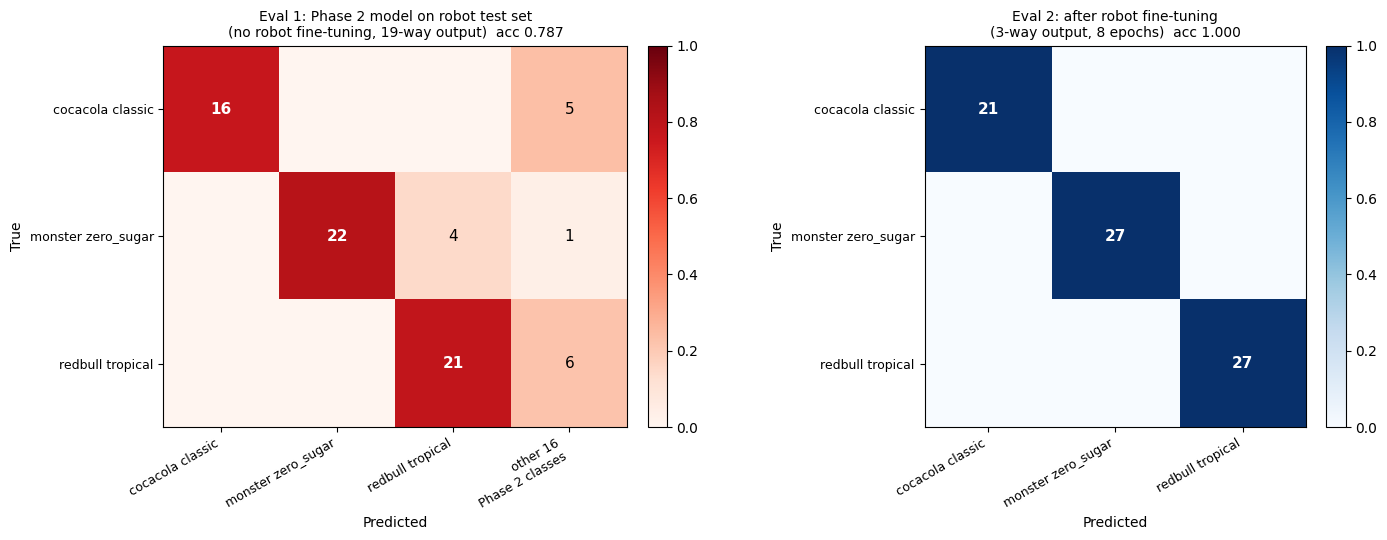

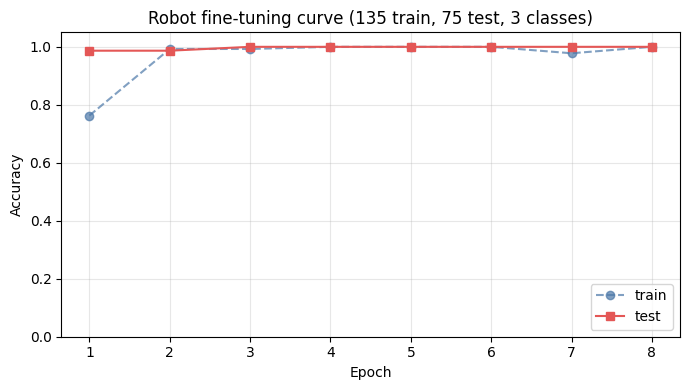


Saved Eval 2 metrics to /content/drive/MyDrive/comp8430_project/outputs/logs/phase3_eval2_metrics.json


In [ ]:
# ============================================================
# Eval 2: full diagnostics on the fine-tuned 3-class model.
#   - Per-class accuracy
#   - 3x3 confusion matrix
#   - Side-by-side comparison with Eval 1
# ============================================================

# Re-run inference to collect predictions and confidences cleanly
@torch.no_grad()
def predict_3way(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        logits = model(imgs)
        all_logits.append(logits.cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_logits), np.concatenate(all_labels)

eval2_logits, eval2_labels = predict_3way(robot_model, robot_test_int_loader)
eval2_probs = torch.softmax(torch.from_numpy(eval2_logits), dim=1).numpy()
eval2_preds = eval2_logits.argmax(axis=1)
eval2_acc   = (eval2_preds == eval2_labels).mean()

# Per-class accuracy
print(f"{'class':<25s} {'n':>4s} {'eval1 strict':>13s} {'eval1 restr':>12s} {'eval2':>7s}")
print("-" * 65)
# Reload eval1 metrics
with open(LOG_DIR / "phase3_eval1_metrics.json") as f:
    eval1 = json.load(f)
for i, cname in enumerate(ROBOT_CLASSES):
    mask = eval2_labels == i
    n = mask.sum()
    e2_acc = (eval2_preds[mask] == i).mean()
    e1 = eval1["per_class"][cname]
    print(f"{cname:<25s} {n:>4d} {e1['strict_acc']:>13.4f} "
          f"{e1['restricted_acc']:>12.4f} {e2_acc:>7.4f}")
print("-" * 65)
print(f"{'OVERALL':<25s} {len(eval2_labels):>4d} "
      f"{eval1['strict_acc_overall']:>13.4f} "
      f"{eval1['restricted_acc_overall']:>12.4f} {eval2_acc:>7.4f}")

# --- 3x3 confusion matrix ---
def cm_3x3(labels, preds):
    cm = np.zeros((3, 3), dtype=int)
    for t, p in zip(labels, preds):
        cm[t, p] += 1
    return cm

# Eval 2 confusion matrix
eval2_cm = cm_3x3(eval2_labels, eval2_preds)

# Eval 1 confusion matrix
eval1_logits_arr = np.load(LOG_DIR / "phase3_eval1_logits.npy")
eval1_preds_p2 = eval1_logits_arr.argmax(axis=1)
# Reload true labels in 3-class index space
true_idx_3 = np.array([ROBOT_CLASS_TO_IDX[n] for n in true_names])
# For each prediction, map to 3-class index or "other" (=3)
robot_p2_indices_set = set(robot_indices_in_phase2)
phase2_to_robot = {p2_idx: ROBOT_CLASS_TO_IDX[c] for c, p2_idx in ROBOT_CLASS_TO_PHASE2_IDX.items()}
eval1_preds_3plus = np.array([
    phase2_to_robot[p] if p in phase2_to_robot else 3   # 3 = "other"
    for p in eval1_preds_p2
])
eval1_cm = np.zeros((3, 4), dtype=int)   # rows: 3 true classes; cols: 3 robot + "other"
for t, p in zip(true_idx_3, eval1_preds_3plus):
    eval1_cm[t, p] += 1

short_names = [c.replace("__", " ") for c in ROBOT_CLASSES]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Eval 1: 3 rows x 4 cols (including "other")
ax = axes[0]
e1_norm = eval1_cm / np.maximum(eval1_cm.sum(axis=1, keepdims=True), 1)
im = ax.imshow(e1_norm, cmap="Reds", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(4))
ax.set_yticks(range(3))
ax.set_xticklabels(short_names + ["other 16\nPhase 2 classes"], rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(short_names, fontsize=9)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Eval 1: Phase 2 model on robot test set\n"
             f"(no robot fine-tuning, 19-way output)  acc {eval1['strict_acc_overall']:.3f}",
             fontsize=10)
for i in range(3):
    for j in range(4):
        cnt = eval1_cm[i, j]
        if cnt == 0: continue
        c = "white" if e1_norm[i, j] > 0.5 else "black"
        ax.text(j, i, str(cnt), ha="center", va="center", color=c,
                fontsize=11, fontweight="bold" if i == j else "normal")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Eval 2: 3x3
ax = axes[1]
e2_norm = eval2_cm / np.maximum(eval2_cm.sum(axis=1, keepdims=True), 1)
im = ax.imshow(e2_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(short_names, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(short_names, fontsize=9)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Eval 2: after robot fine-tuning\n"
             f"(3-way output, 8 epochs)  acc {eval2_acc:.3f}",
             fontsize=10)
for i in range(3):
    for j in range(3):
        cnt = eval2_cm[i, j]
        if cnt == 0: continue
        c = "white" if e2_norm[i, j] > 0.5 else "black"
        ax.text(j, i, str(cnt), ha="center", va="center", color=c,
                fontsize=11, fontweight="bold" if i == j else "normal")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIG_DIR / "eval1_vs_eval2_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Training/test curve ---
fig2, ax = plt.subplots(figsize=(7, 4))
epochs = range(1, len(history["train_acc"]) + 1)
ax.plot(epochs, history["train_acc"], linestyle="--", marker="o",
        color="#4C78A8", label="train", alpha=0.7)
ax.plot(epochs, history["test_acc_per_epoch"], linestyle="-", marker="s",
        color="#E45756", label="test")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title(f"Robot fine-tuning curve (135 train, 75 test, 3 classes)")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "robot_finetune_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# Save Eval 2 metrics
with open(LOG_DIR / "phase3_eval2_metrics.json", "w") as f:
    json.dump({
        "n_test": int(len(eval2_labels)),
        "test_acc_overall": float(eval2_acc),
        "per_class": {
            ROBOT_IDX_TO_CLASS[i]: {
                "n": int((eval2_labels == i).sum()),
                "test_acc": float((eval2_preds[eval2_labels == i] == i).mean()),
            } for i in range(ROBOT_NUM_CLASSES)
        },
        "history": history,
    }, f, indent=2)
print(f"\nSaved Eval 2 metrics to {LOG_DIR / 'phase3_eval2_metrics.json'}")